# Population-Adjusted Bicycle-Theft Analysis

**Theft-report period:** 1 January 2025–8 August 2026  
**Population reference date:** 31 December 2025

## Purpose

This notebook compares police-recorded bicycle-theft counts across Berlin
districts before and after adjusting for population size.

The population-adjusted measure is:

**reported incidents ÷ population × 10,000**

This is not a direct measure of personal theft risk because the data does not
include the number of bicycles, commuters, tourists or unreported thefts.

In [2]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
import pandas as pd

project_path = "/content/drive/MyDrive/Dude_Wheres_My_Bike_Project"

population_path = (
    project_path
    + "/01_Data/raw/EWR_L21_202512E_Matrix.csv"
)

population_raw = pd.read_csv(
    population_path,
    sep=";",
    dtype={
        "RAUMID": "string",
        "BEZ": "string",
        "PGR": "string",
        "BZR": "string",
        "PLR": "string",
        "BEZPGR": "string"
    }
)

print("Rows and columns:", population_raw.shape)
print("Planning areas:", population_raw["RAUMID"].nunique())
print("Population date:", population_raw["ZEIT"].unique())
print("Total population:", population_raw["E_E"].sum())

population_raw[["RAUMID", "BEZ", "E_E"]].head()

Rows and columns: (542, 51)
Planning areas: 542
Population date: [202512]
Total population: 3913644.0


,RAUMID,BEZ,E_E
0,01100101,01,3469.0
1,01100102,01,2082.0
2,01100103,01,5832.0
3,01100104,01,4966.0
4,01100205,01,2950.0


In [4]:
# Checking missing population values

missing_population = population_raw[
    population_raw["E_E"].isna()
][["RAUMID", "BEZ", "PGR", "BZR", "PLR", "E_E"]]

print("Planning areas with missing population:", len(missing_population))

display(missing_population)

Planning areas with missing population: 2


,RAUMID,BEZ,PGR,BZR,PLR,E_E
115,03400831,03,40,08,31,NaN
260,06200418,06,20,04,18,NaN


In [6]:
# Loading the canonical bicycle-theft dataset

theft_path = (
    project_path
    + "/01_Data/processed/analysis_ready_v2.csv"
)

theft = pd.read_csv(
    theft_path,
    encoding="utf-8-sig",
    dtype={
        "lor": "string",
        "district_id": "string"
    }
)

# Converting the relevant date columns
date_columns = [
    "record_created_date",
    "offence_start_date",
    "offence_end_date"
]

for column in date_columns:
    theft[column] = pd.to_datetime(
        theft[column],
        errors="coerce"
    )

print("Rows and columns:", theft.shape)
print(
    "Study period:",
    theft["offence_start_date"].min(),
    "to",
    theft["offence_start_date"].max()
)
print("Districts represented:", theft["district_name"].nunique())
print("Planning areas represented:", theft["lor"].nunique())
print("Invalid dates:", theft["offence_start_date"].isna().sum())
print("All LOR codes have 8 characters:", theft["lor"].str.len().eq(8).all())

theft[
    ["offence_start_date", "lor", "district_id", "district_name"]
].head()

Rows and columns: (26965, 34)
Study period: 2025-01-01 00:00:00 to 2026-08-08 00:00:00
Districts represented: 12
Planning areas represented: 534
Invalid dates: 0
All LOR codes have 8 characters: True


,offence_start_date,lor,district_id,district_name
0,2026-08-08,01200521,01,Mitte
1,2026-08-01,03601347,03,Pankow
2,2026-08-08,01200521,01,Mitte
3,2026-08-05,03701554,03,Pankow
4,2026-08-08,11401034,11,Lichtenberg


In [7]:
# Creating district population totals

district_population = (
    population_raw
    .groupby("BEZ", as_index=False)
    .agg(population=("E_E", "sum"))
    .rename(columns={"BEZ": "district_id"})
)

# Creating theft-report totals for the full study period
district_reports = (
    theft
    .groupby(["district_id", "district_name"], as_index=False)
    .size()
    .rename(columns={"size": "reported_incidents"})
)

# Joining reports and population
district_adjusted = district_reports.merge(
    district_population,
    on="district_id",
    how="left",
    validate="one_to_one"
)

# Calculating cumulative reports per 10,000 residents
district_adjusted["reports_per_10000"] = (
    district_adjusted["reported_incidents"]
    / district_adjusted["population"]
    * 10000
)

# Adding both rankings
district_adjusted["total_report_rank"] = (
    district_adjusted["reported_incidents"]
    .rank(method="min", ascending=False)
    .astype(int)
)

district_adjusted["population_adjusted_rank"] = (
    district_adjusted["reports_per_10000"]
    .rank(method="min", ascending=False)
    .astype(int)
)

# Sorting by population-adjusted result
district_adjusted = district_adjusted.sort_values(
    "reports_per_10000",
    ascending=False
).reset_index(drop=True)

district_adjusted["reports_per_10000"] = (
    district_adjusted["reports_per_10000"].round(1)
)

display(district_adjusted)

print("Districts in result:", len(district_adjusted))
print("Missing population totals:", district_adjusted["population"].isna().sum())
print("Total reports:", district_adjusted["reported_incidents"].sum())
print("Total population:", district_adjusted["population"].sum())

,district_id,district_name,reported_incidents,population,reports_per_10000,total_report_rank,population_adjusted_rank
0,02,Friedrichshain-Kreuzberg,4001,292789.0,136.7,2,1
1,01,Mitte,5130,397879.0,128.9,1,2
2,03,Pankow,3193,428900.0,74.4,3,3
3,04,Charlottenburg-Wilmersdorf,2476,343625.0,72.1,4,4
4,07,Tempelhof-Schöneberg,2469,358835.0,68.8,5,5
5,08,Neukölln,2041,331623.0,61.5,6,6
6,09,Treptow-Köpenick,1758,302686.0,58.1,8,7
7,11,Lichtenberg,1795,318261.0,56.4,7,8
8,06,Steglitz-Zehlendorf,1628,309338.0,52.6,9,9
9,12,Reinickendorf,1037,271755.0,38.2,10,10


Districts in result: 12
Missing population totals: 0
Total reports: 26965
Total population: 3913644.0


In [8]:
# Displaying the final district comparison clearly

comparison_columns = [
    "district_name",
    "reported_incidents",
    "population",
    "reports_per_10000",
    "total_report_rank",
    "population_adjusted_rank"
]

display(
    district_adjusted[comparison_columns].style.format({
        "reported_incidents": "{:,.0f}",
        "population": "{:,.0f}",
        "reports_per_10000": "{:.1f}"
    })
)

,district_name,reported_incidents,population,reports_per_10000,total_report_rank,population_adjusted_rank
0,Friedrichshain-Kreuzberg,"4,001","292,789",136.7,2,1
1,Mitte,"5,130","397,879",128.9,1,2
2,Pankow,"3,193","428,900",74.4,3,3
3,Charlottenburg-Wilmersdorf,"2,476","343,625",72.1,4,4
4,Tempelhof-Schöneberg,"2,469","358,835",68.8,5,5
5,Neukölln,"2,041","331,623",61.5,6,6
6,Treptow-Köpenick,"1,758","302,686",58.1,8,7
7,Lichtenberg,"1,795","318,261",56.4,7,8
8,Steglitz-Zehlendorf,"1,628","309,338",52.6,9,9
9,Reinickendorf,"1,037","271,755",38.2,10,10


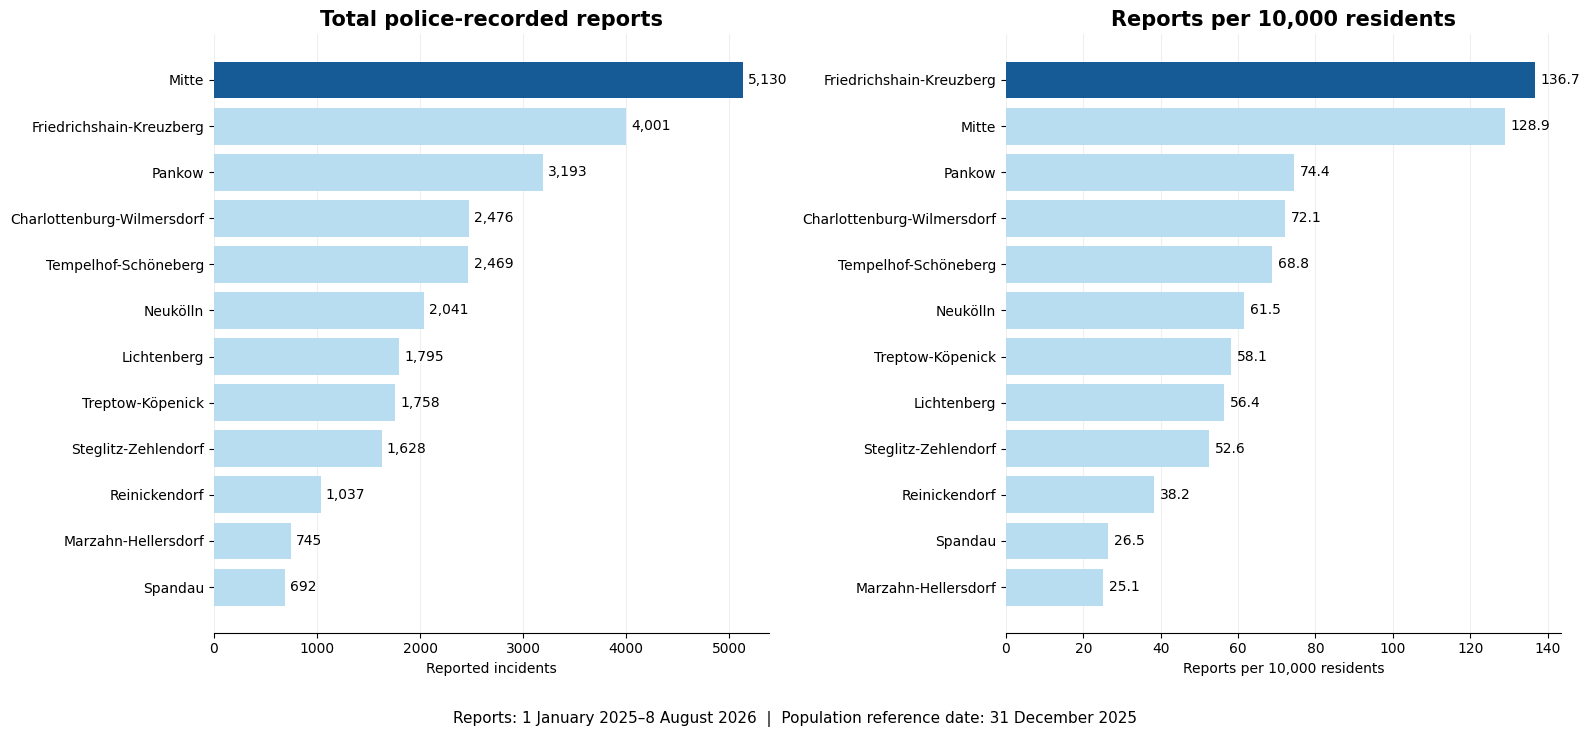

In [24]:
import matplotlib.pyplot as plt

# Separate sorting for each chart
count_chart = district_adjusted.sort_values(
    "reported_incidents",
    ascending=True
)

adjusted_chart = district_adjusted.sort_values(
    "reports_per_10000",
    ascending=True
)

# Highlight the leading district in each chart
count_colors = [
    "#165A96" if name == "Mitte" else "#B9DDF0"
    for name in count_chart["district_name"]
]

adjusted_colors = [
    "#165A96" if name == "Friedrichshain-Kreuzberg" else "#B9DDF0"
    for name in adjusted_chart["district_name"]
]

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Left chart: total reports
axes[0].barh(
    count_chart["district_name"],
    count_chart["reported_incidents"],
    color=count_colors
)

axes[0].set_title(
    "Total police-recorded reports",
    fontsize=15,
    fontweight="bold"
)
axes[0].set_xlabel("Reported incidents")

for index, value in enumerate(count_chart["reported_incidents"]):
    axes[0].text(
        value + 50,
        index,
        f"{value:,.0f}",
        va="center"
    )

# Right chart: population-adjusted reports
axes[1].barh(
    adjusted_chart["district_name"],
    adjusted_chart["reports_per_10000"],
    color=adjusted_colors
)

axes[1].set_title(
    "Reports per 10,000 residents",
    fontsize=15,
    fontweight="bold"
)
axes[1].set_xlabel("Reports per 10,000 residents")

for index, value in enumerate(adjusted_chart["reports_per_10000"]):
    axes[1].text(
        value + 1.5,
        index,
        f"{value:.1f}",
        va="center"
    )

for axis in axes:
    axis.grid(axis="x", alpha=0.2)
    axis.set_axisbelow(True)
    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)
    axis.spines["left"].set_visible(False)


fig.text(
    0.5,
    0.02,
    "Reports: 1 January 2025–8 August 2026  |  "
    "Population reference date: 31 December 2025",
    ha="center",
    fontsize=11
)

plt.tight_layout(rect=[0, 0.06, 1, 0.93])
plt.show()

In [10]:
# Preparing the verified district table for Tableau

tableau_export = district_adjusted.copy()

tableau_export["report_period"] = (
    "2025-01-01 to 2026-08-08"
)

tableau_export["population_reference_date"] = (
    "2025-12-31"
)

export_path = (
    project_path
    + "/01_Data/processed/"
    + "district_population_adjusted_v1.csv"
)

tableau_export.to_csv(
    export_path,
    index=False,
    encoding="utf-8-sig"
)

print("File saved successfully:")
print(export_path)
print("Exported shape:", tableau_export.shape)

File saved successfully:
/content/drive/MyDrive/Dude_Wheres_My_Bike_Project/01_Data/processed/district_population_adjusted_v1.csv
Exported shape: (12, 9)


In [11]:
# Verifying that the exported CSV can be reopened correctly

export_check = pd.read_csv(
    export_path,
    encoding="utf-8-sig",
    dtype={"district_id": "string"}
)

print("Reopened shape:", export_check.shape)
print("Districts:", export_check["district_name"].nunique())
print("Total reports:", export_check["reported_incidents"].sum())
print("Total population:", export_check["population"].sum())
print("Missing values:", export_check.isna().sum().sum())

display(export_check.head())

Reopened shape: (12, 9)
Districts: 12
Total reports: 26965
Total population: 3913644.0
Missing values: 0


,district_id,district_name,reported_incidents,population,reports_per_10000,total_report_rank,population_adjusted_rank,report_period,population_reference_date
0,02,Friedrichshain-Kreuzberg,4001,292789.0,136.7,2,1,2025-01-01 to 2026-08-08,2025-12-31
1,01,Mitte,5130,397879.0,128.9,1,2,2025-01-01 to 2026-08-08,2025-12-31
2,03,Pankow,3193,428900.0,74.4,3,3,2025-01-01 to 2026-08-08,2025-12-31
3,04,Charlottenburg-Wilmersdorf,2476,343625.0,72.1,4,4,2025-01-01 to 2026-08-08,2025-12-31
4,07,Tempelhof-Schöneberg,2469,358835.0,68.8,5,5,2025-01-01 to 2026-08-08,2025-12-31


In [17]:
# real report found in our dataset
report = theft[
    (theft["offence_start_date"] == pd.Timestamp("2026-03-28")) &
    (theft["offence_start_hour"] == 15) &
    (theft["offence_end_date"] == pd.Timestamp("2026-03-28")) &
    (theft["offence_end_hour"] == 16) &
    (theft["lor"] == "04501042") &
    (theft["reported_damage_eur"] == 900)
]

display(report)

,record_created_date,offence_start_date,offence_start_hour,offence_end_date,offence_end_hour,lor,reported_damage_eur,attempt,bicycle_type,offence_category,...,is_cellar_location,is_duplicate_copy,is_comparable_ytd,district_id,district_name,forecast_area_id,forecast_area_name,district_region_id,district_region_name,planning_area_name
6486,2026-04-13,2026-03-28,15,2026-03-28,16,04501042,900,Nein,Herrenfahrrad,Fahrraddiebstahl,...,False,False,True,04,Charlottenburg-Wilmersdorf,450,Wilmersdorf Zentrum,45010,Lietzenburger Straße,Breitscheidplatz


In [18]:
display(
    report[
        [
            "offence_start_date",
            "offence_start_hour",
            "offence_end_date",
            "offence_end_hour",
            "district_name",
            "planning_area_name",
            "bicycle_type",
            "reported_damage_eur",
            "attempt"
        ]
    ]
)

,offence_start_date,offence_start_hour,offence_end_date,offence_end_hour,district_name,planning_area_name,bicycle_type,reported_damage_eur,attempt
6486,2026-03-28,15,2026-03-28,16,Charlottenburg-Wilmersdorf,Breitscheidplatz,Herrenfahrrad,900,Nein
